In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
import pandas as pd

df = pd.read_excel("your_dataset.xlsx")

df["Timestamp"] = pd.to_datetime(
    df["Timestamp"],
    dayfirst=True,     # because your dates are DD-MM-YYYY
    errors="coerce"    # invalid rows become NaT instead of crashing
)

# remove rows where Timestamp couldn't be parsed
df = df.dropna(subset=["Timestamp"])

df.head(10)

,Timestamp,Demand (MW),Wind (MW),Solar (MW),Total Generation (MW)
0,2024-01-01 00:00:00,141981.26,9545.07,20.29,142193.38
1,2024-01-01 01:00:00,138675.49,9027.05,19.96,138792.04
2,2024-01-01 02:00:00,136122.78,8241.48,19.79,136796.02
3,2024-01-01 03:00:00,135806.51,7866.09,19.73,136859.67
4,2024-01-01 04:00:00,139905.77,7430.71,20.02,140561.49
5,2024-01-01 05:00:00,149576.68,6782.87,18.55,150273.8
6,2024-01-01 06:00:00,164183.48,5908.15,107.84,165184.35
7,2024-01-01 07:00:00,181403.35,5622.79,1570.77,182050.07
8,2024-01-01 08:00:00,195020.24,5153.53,9518.41,195333.03
9,2024-01-01 09:00:00,203050.27,3650.12,19207.05,203394.21


In [3]:
df["Hour"] = df["Timestamp"].dt.hour
df["Day"] = df["Timestamp"].dt.day
df["Month"] = df["Timestamp"].dt.month

In [4]:
X_solar = df[["Wind (MW)", "Demand (MW)", "Hour", "Month"]]

y_solar = df["Solar (MW)"]

In [5]:
Xs_train, Xs_test, ys_train, ys_test = train_test_split(
    X_solar, y_solar, test_size=0.2, random_state=42
)

In [6]:
solar_model = GradientBoostingRegressor()

solar_model.fit(Xs_train, ys_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [7]:
solar_pred = solar_model.predict(Xs_test)

In [8]:
mae_solar = mean_absolute_error(ys_test, solar_pred)
rmse_solar = np.sqrt(mean_squared_error(ys_test, solar_pred))
r2_solar = r2_score(ys_test, solar_pred)

print("Solar Model Performance")
print("MAE:", mae_solar)
print("RMSE:", rmse_solar)
print("R2:", r2_solar)

Solar Model Performance
MAE: 2591.4381333372235
RMSE: 4587.988355911648
R2: 0.9454689081065869


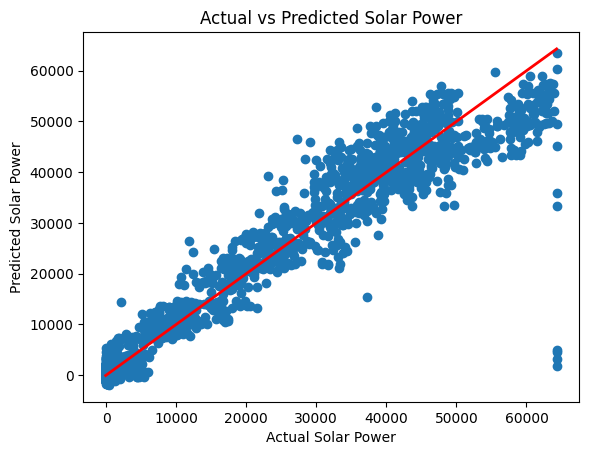

In [9]:
plt.scatter(ys_test, solar_pred)


plt.plot(
    [ys_test.min(), ys_test.max()],
    [ys_test.min(), ys_test.max()],
    color='red',
    linewidth=2
)

plt.xlabel("Actual Solar Power")
plt.ylabel("Predicted Solar Power")
plt.title("Actual vs Predicted Solar Power")

plt.show()

In [10]:
X_wind = df[["Solar (MW)", "Demand (MW)", "Hour", "Month"]]

y_wind = df["Wind (MW)"]

In [11]:
Xw_train, Xw_test, yw_train, yw_test = train_test_split(
    X_wind, y_wind, test_size=0.2, random_state=42
)

In [12]:
wind_model = GradientBoostingRegressor()

wind_model.fit(Xw_train, yw_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [13]:
wind_pred = wind_model.predict(Xw_test)

In [14]:
mae_wind = mean_absolute_error(yw_test, wind_pred)
rmse_wind = np.sqrt(mean_squared_error(yw_test, wind_pred))
r2_wind = r2_score(yw_test, wind_pred)

print("Wind Model Performance")
print("MAE:", mae_wind)
print("RMSE:", rmse_wind)
print("R2:", r2_wind)

Wind Model Performance
MAE: 2597.7347235234156
RMSE: 3546.6566296321275
R2: 0.6268173799947316


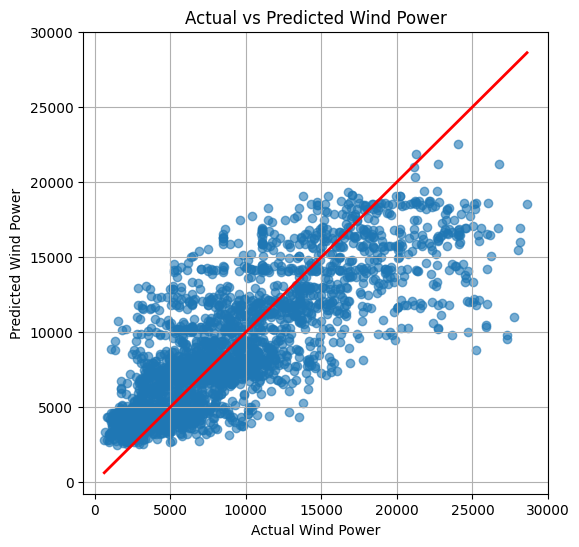

In [15]:
plt.figure(figsize=(6,6))

plt.scatter(yw_test, wind_pred, alpha=0.6)

# perfect prediction line
plt.plot(
    [yw_test.min(), yw_test.max()],
    [yw_test.min(), yw_test.max()],
    color='red',
    linewidth=2
)

plt.xlabel("Actual Wind Power")
plt.ylabel("Predicted Wind Power")
plt.title("Actual vs Predicted Wind Power")

plt.grid(True)

plt.show()

In [16]:
results = pd.DataFrame({
    "Actual_Solar": ys_test,
    "Predicted_Solar": solar_pred,
    "Actual_Wind": yw_test,
    "Predicted_Wind": wind_pred
})

results.to_csv("renewable_predictions.csv", index=False)

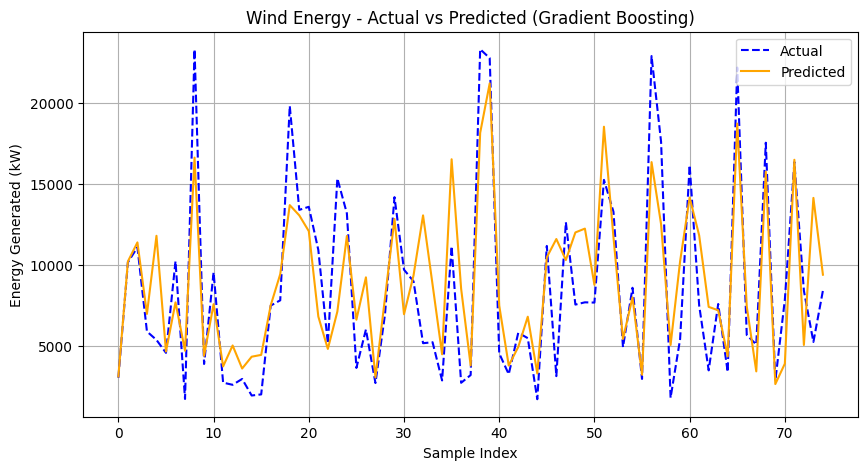

In [17]:
import matplotlib.pyplot as plt
import numpy as np

actual = np.array(yw_test)
predicted = np.array(wind_pred)


n_samples = 75

plt.figure(figsize=(10,5))

plt.plot(actual[:n_samples], linestyle='--', color='blue', label='Actual')
plt.plot(predicted[:n_samples], color='orange', label='Predicted')

plt.title("Wind Energy - Actual vs Predicted (Gradient Boosting)")
plt.xlabel("Sample Index")
plt.ylabel("Energy Generated (kW)")

plt.legend()
plt.grid(True)

plt.show()

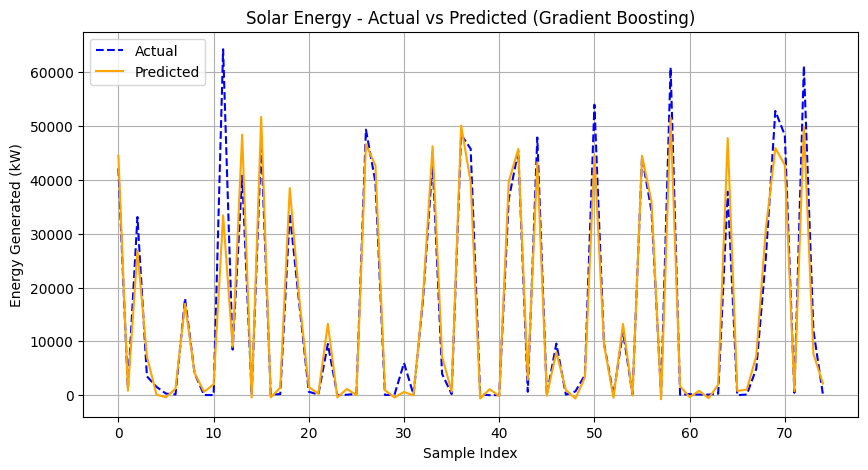

In [18]:
actual_solar = np.array(ys_test)
predicted_solar = np.array(solar_pred)

n_samples = 75

plt.figure(figsize=(10,5))

plt.plot(actual_solar[:n_samples], linestyle='--', color='blue', label='Actual')
plt.plot(predicted_solar[:n_samples], color='orange', label='Predicted')

plt.title("Solar Energy - Actual vs Predicted (Gradient Boosting)")
plt.xlabel("Sample Index")
plt.ylabel("Energy Generated (kW)")

plt.legend()
plt.grid(True)

plt.show()

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_solar = mean_absolute_error(ys_test, solar_pred)
mse_solar = mean_squared_error(ys_test, solar_pred)
rmse_solar = np.sqrt(mse_solar)
r2_solar = r2_score(ys_test, solar_pred)

print("Solar Model Evaluation Metrics")
print("MAE:", mae_solar)
print("MSE:", mse_solar)
print("RMSE:", rmse_solar)
print("R² Score:", r2_solar)

Solar Model Evaluation Metrics
MAE: 2591.4381333372235
MSE: 21049637.15398087
RMSE: 4587.988355911648
R² Score: 0.9454689081065869


In [20]:
mae_wind = mean_absolute_error(yw_test, wind_pred)
mse_wind = mean_squared_error(yw_test, wind_pred)
rmse_wind = np.sqrt(mse_wind)
r2_wind = r2_score(yw_test, wind_pred)

print("Wind Model Evaluation Metrics")
print("MAE:", mae_wind)
print("MSE:", mse_wind)
print("RMSE:", rmse_wind)
print("R² Score:", r2_wind)

Wind Model Evaluation Metrics
MAE: 2597.7347235234156
MSE: 12578773.248513522
RMSE: 3546.6566296321275
R² Score: 0.6268173799947316
